<a href="https://colab.research.google.com/github/wenh08/Python_projects-/blob/main/PythonClassProject1_311Datasetipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')

/tmp/ipykernel_3392/573492825.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv')


In [3]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420.0,127-16 111 AVENUE,111 AVENUE,ADDRESS,...,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4.116320e+09,QUEENS,40.682565,-73.814060,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011.0,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1.007640e+09,MANHATTAN,40.738791,-74.000224,"(40.738790792032844, -74.00022373020307)"
2,42527619,5/1/2019 0:00,5/13/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10025.0,2664 BROADWAY,BROADWAY,ADDRESS,...,NaN,NaN,Closed,5/15/2019 10:04,The Department of Health and Mental Hygiene wi...,1.018730e+09,MANHATTAN,40.798040,-73.969300,"(40.79804015465285, -73.96930001020544)"
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208.0,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3.042380e+09,BROOKLYN,40.675905,-73.866660,"(40.67590510222738, -73.86665990579837)"
4,42526595,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11106.0,31-91 21 STREET,21 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:12,The Department of Health and Mental Hygiene wi...,4.005540e+09,QUEENS,40.765367,-73.931540,"(40.76536704921336, -73.93154011254339)"


In [4]:
# How many rows and columns are in this dataset?
#There are 69637 rows and 21 columns

df.shape


(69637, 21)

In [ ]:
(df.columns)

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Landmark', 'Facility Type', 'Status',
       'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')


In [3]:
#what is the time range of this dataset?
# May 1st-May 10th 2019

df['Created Date'] = pd.to_datetime(df['Created Date'])
print( df['Created Date'].min())
print(df['Created Date'].max())


2019-05-01 00:00:00
2019-05-10 00:00:00


In [20]:
#what are some relevant summary statistics


Illegal_parking = df[df["Complaint Type"] == "Illegal Parking"]

#here we are filtering for only complaints named illgal parking and saving them as Illegal_parking
# Here we can see that Queen has the most parking compliants, and staten island has the least


Illegal_parking.groupby(['Borough'])['Unique Key'].count().sort_values(ascending=False)




,Unique Key
Borough,
QUEENS,1738
BROOKLYN,1658
MANHATTAN,886
BRONX,658
STATEN ISLAND,307
Unspecified,10


In [21]:
#Here we had a row named Unspecified because there are rows that did not list a borough, we renamed that to within_nyc

illegal_parking["Borough"] = illegal_parking["Borough"].replace(
    "Unspecified", "Within_NYC"
)
illegal_parking.groupby("Borough").size().sort_values(ascending=False)


/tmp/ipykernel_3392/1704919835.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  illegal_parking["Borough"] = illegal_parking["Borough"].replace(


,0
Borough,
QUEENS,1738
BROOKLYN,1658
MANHATTAN,886
BRONX,658
STATEN ISLAND,307
Within_NYC,10


In [ ]:
# To answer the summary statistics by percentage
illegal_parking["Borough"].value_counts(normalize=True) * 100

,proportion
Borough,
QUEENS,33.060681
BROOKLYN,31.538901
MANHATTAN,16.853719
BRONX,12.516644
STATEN ISLAND,5.839833
Within_NYC,0.190223


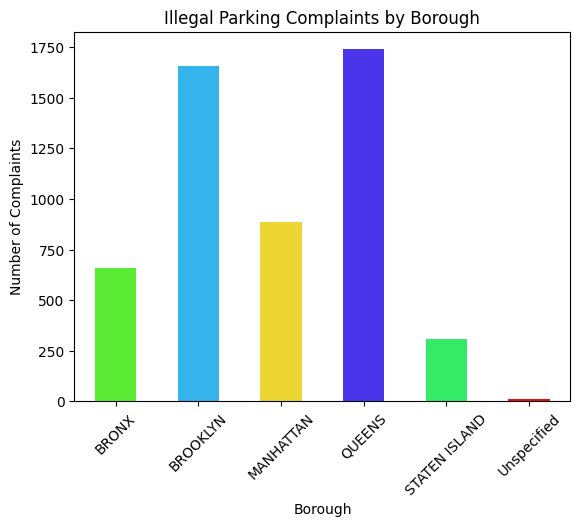

In [27]:
# create 2-3 visualizations from this dataset


Illegal_parking.groupby(['Borough'])['Unique Key'].count().plot(
    kind = 'bar',
    color =['#5beb34', '#34b4eb', '#ebd634', '#4c34eb', '#34eb68', '#f00c0c'])
plt.title('Illegal Parking Complaints by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Complaints')
plt.xticks(rotation =45)
plt.show()

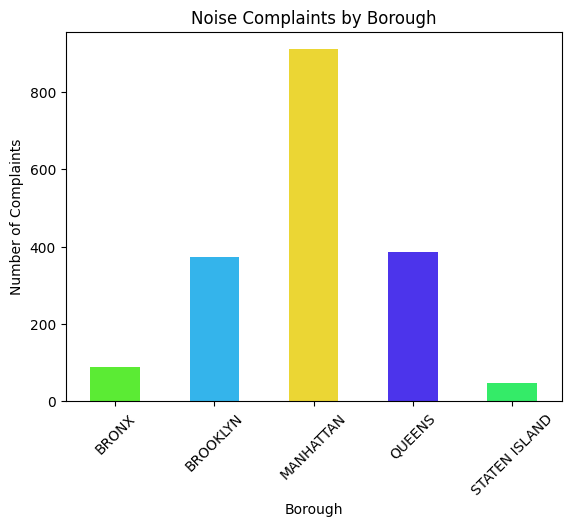

In [37]:
#create a plot of counts by borough for noise complaints / Adding this to my 2nd visualizations
#here we can see that manhattan has the most noise complaints by borough

Noise_complaints = df[df['Complaint Type'] == 'Noise']

Noise_complaints.groupby(['Borough'])['Unique Key'].count().plot(
    kind = 'bar', color =['#5beb34', '#34b4eb', '#ebd634', '#4c34eb', '#34eb68']
    )
plt.title ('Noise Complaints by Borough')
plt.xlabel('Borough')
plt.ylabel ('Number of Complaints')
plt.xticks(rotation =45)
plt.show()



In [39]:
# what borough had the most complaints ?
# here we can see that brooklyn had the most complaints by borough

complaints_by_borough = df.groupby('Borough')['Unique Key'].count().sort_values(ascending = False)
complaints_by_borough

,Unique Key
Borough,
BROOKLYN,22247
QUEENS,18623
MANHATTAN,13133
BRONX,10925
STATEN ISLAND,3848
Unspecified,861


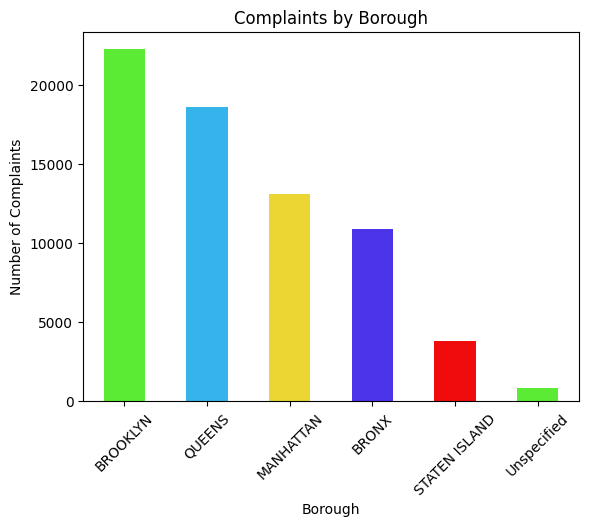

In [45]:
# to graph the most complaints by borough

complaints_by_borough.plot(kind = 'bar', color =['#5beb34', '#34b4eb', '#ebd634', '#4c34eb', '#f00c0c'])
plt.title('Complaints by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Complaints')
plt.xticks(rotation =45)
plt.show()


